# PROJECT_GOOGLEPLAYSTORE_APPS

In [12]:
import pandas as pd

# Load datasets
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

In [13]:
# View first 5 rows
print(apps_df.head())
print(reviews_df.head())

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

In [14]:

# Check dataset shape
print("Apps Dataset Shape:", apps_df.shape)
print("Reviews Dataset Shape:", reviews_df.shape)

# Check data types
print(apps_df.info())
print(reviews_df.info())


Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (to

In [15]:
apps_df.drop_duplicates(inplace=True)
reviews_df.drop_duplicates(inplace=True)


In [16]:
# Fill missing values with median or most frequent
apps_df['Rating'].fillna(apps_df['Rating'].median(), inplace=True)
apps_df['Type'].fillna(apps_df['Type'].mode()[0], inplace=True)
apps_df['Content Rating'].fillna(apps_df['Content Rating'].mode()[0], inplace=True)
apps_df['Current Ver'].fillna(apps_df['Current Ver'].mode()[0], inplace=True)
apps_df['Android Ver'].fillna(apps_df['Android Ver'].mode()[0], inplace=True)


In [17]:
# Fill missing values for review text and sentiment
reviews_df['Translated_Review'].fillna('No Review', inplace=True)
reviews_df['Sentiment'].fillna('Unknown', inplace=True)
reviews_df['Sentiment_Polarity'].fillna(0, inplace=True)
reviews_df['Sentiment_Subjectivity'].fillna(0, inplace=True)


In [18]:
apps_df['Installs'] = apps_df['Installs'].str.replace('[+,]', '', regex=True)
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce').fillna(0).astype(int)

apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=True)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce').fillna(0)

apps_df['Size'] = apps_df['Size'].replace('Varies with device', '0')
apps_df['Size'] = apps_df['Size'].str.replace('[Mk]', '', regex=True)
apps_df['Size'] = pd.to_numeric(apps_df['Size'], errors='coerce').fillna(0)


In [19]:
apps_df = apps_df[apps_df['Rating'] <= 5]


In [20]:
# checking the cleaned Data set
print("Cleaned Apps Dataset Shape:", apps_df.shape)
print("Cleaned Reviews Dataset Shape:", reviews_df.shape)
print(apps_df.head())


Cleaned Apps Dataset Shape: (10357, 13)
Cleaned Reviews Dataset Shape: (30679, 5)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size  Installs  Type  Price Content Rating  \
0     159  19.0     10000  Free    0.0       Everyone   
1     967  14.0    500000  Free    0.0       Everyone   
2   87510   8.7   5000000  Free    0.0       Everyone   
3  215644  25.0  50000000  Free    0.0           Teen   
4     967   2.8    100000  Free    0.0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & De

# Visulaizations

## Visualization 1 – Category Distribution (Number of Apps per Category)

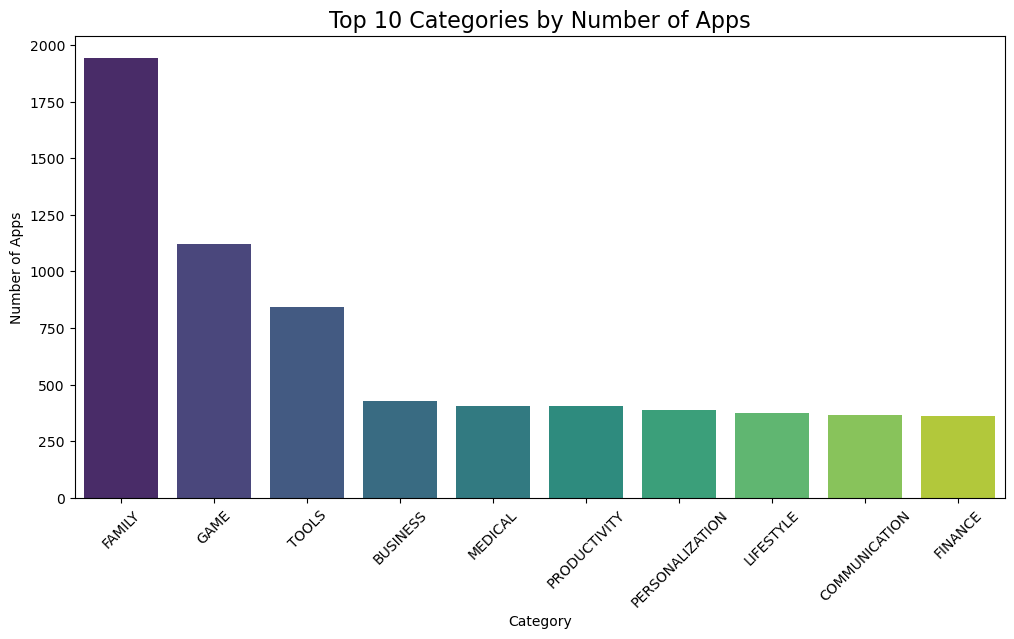

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of apps per category
category_counts = apps_df['Category'].value_counts().head(10)  # Top 10 categories

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Top 10 Categories by Number of Apps", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.show()

## Visualization 2 – Top Categories by Installs (Popularity)

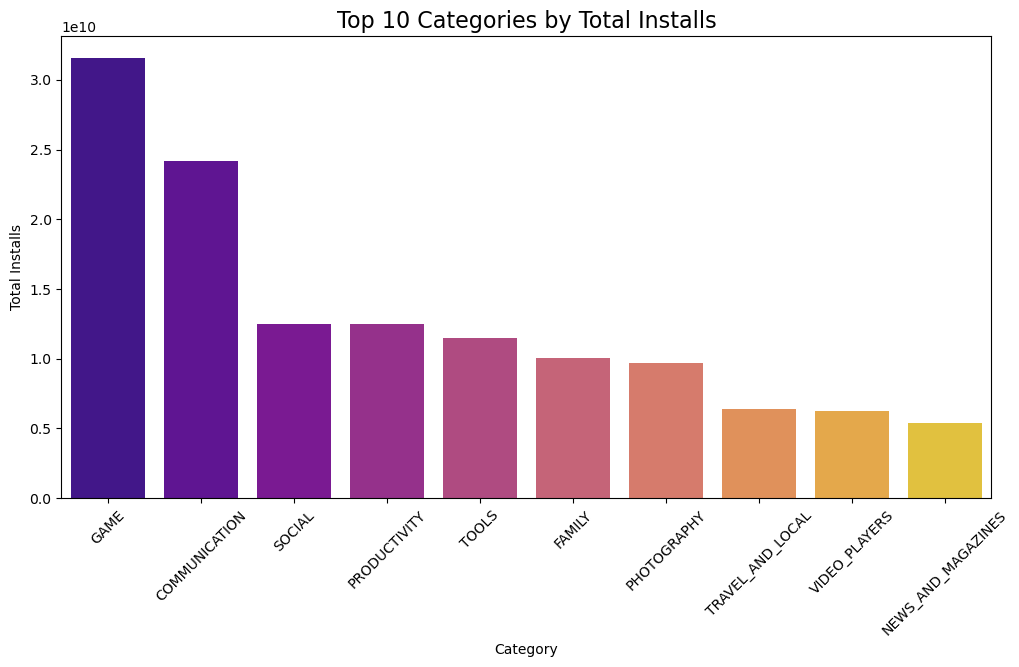

In [28]:
# Group by Category and sum the Installs
category_installs = apps_df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=category_installs.index, y=category_installs.values, palette="plasma")
plt.xticks(rotation=45)
plt.title("Top 10 Categories by Total Installs", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.show()

## Visualization 3 – Free vs Paid App Distribution

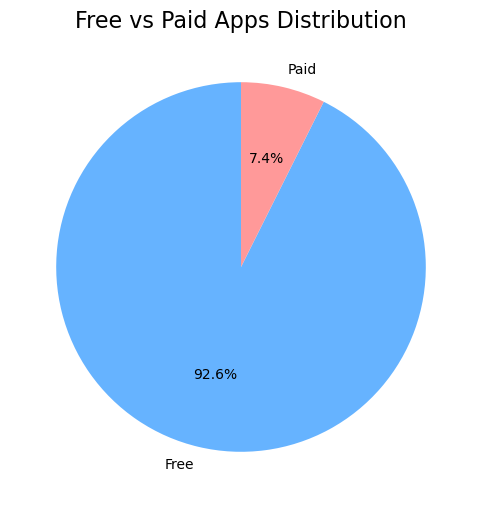

In [29]:
# Count Free vs Paid Apps
type_counts = apps_df['Type'].value_counts()

# Plot
plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title("Free vs Paid Apps Distribution", fontsize=16)
plt.show()

## Visualization 4 – Average Rating by Category

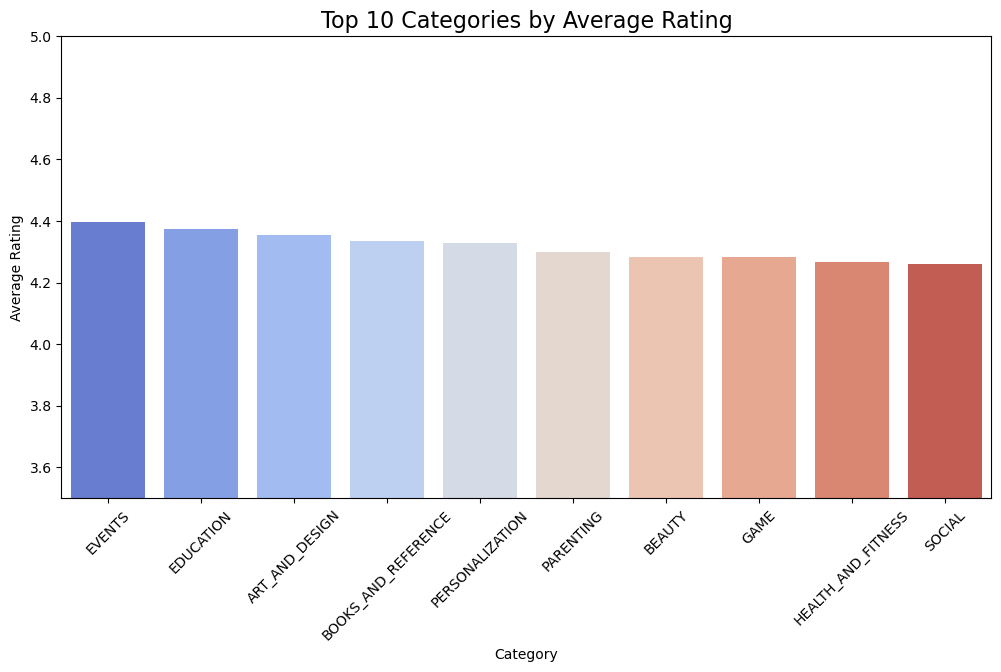

In [30]:
# Calculate average rating per category
avg_rating_category = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=avg_rating_category.index, y=avg_rating_category.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Top 10 Categories by Average Rating", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(3.5, 5)  # Ratings are usually between 3.5 and 5
plt.show()

## Visualization 5 – Sentiment Analysis of User Reviews

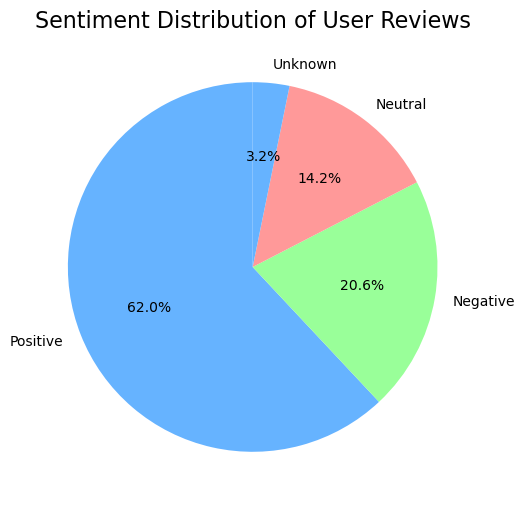

In [31]:
# Count of sentiments
sentiment_counts = reviews_df['Sentiment'].value_counts()

# Plot
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#66b3ff','#99ff99','#ff9999'])
plt.title("Sentiment Distribution of User Reviews", fontsize=16)
plt.show()

# ML_Model

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Filter dataset: only rows with sentiment labels
reviews_clean = reviews_df[reviews_df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

# Features and labels
X = reviews_clean['Translated_Review']
y = reviews_clean['Sentiment']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_vec = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

In [37]:
# Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8572390572390572
              precision    recall  f1-score   support

    Negative       0.89      0.62      0.73      1307
     Neutral       0.76      0.85      0.80       840
    Positive       0.87      0.94      0.90      3793

    accuracy                           0.86      5940
   macro avg       0.84      0.80      0.81      5940
weighted avg       0.86      0.86      0.85      5940



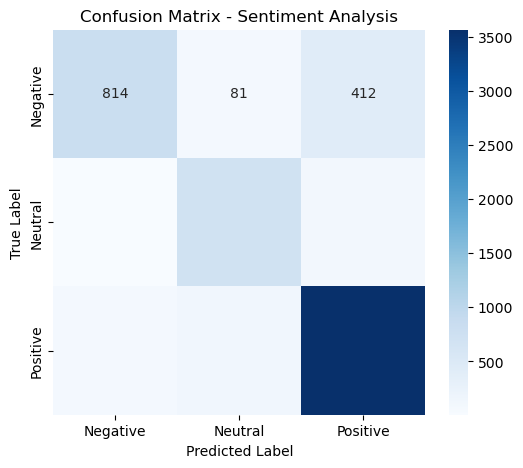

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Sentiment Analysis')
plt.show()